# Computational Thinking (CT)

"Computational Thinking is the thought processes involved in formulating problems and their solutions so that the solutions are represented in a form that can be effectively carried out by an information-processing agent." Cuny, Snyder, Wing (Carnegie Mellon University)

CT is a problem solving process that is essential to the development of computer applications, but it can also be used to support general problem solving in all disciplines. As you personally apply CT more broadly, you will begin to see relationships between things inside and outside of the classroom. (Google)

Computational thinking means creating and making use of different levels of abstraction, to understand and solve problems more effectively. Computational thinking means thinking algorithmically and with the ability to apply mathematical concepts such as induction to develop more efficient, fair, and secure solutions.  Computational thinking means understanding the consequences of scale, not only for reasons of efficiency but also for economic and social reasons. (CMU Center for CT)

It is helpful to think about CT as a process consisting of:
1. Decomposition: Breaking down data, processes, or problems into smaller, manageable parts
2. Pattern Recognition: Observing patterns, trends, and regularities in data
3. Abstraction: Identifying the general principles that generate these patterns
4. Algorithm Design: Developing the step by step instructions for solving this and similar problems

This module is about applying computational thinking to classical and real-world computing problems.  The language of choice for expressing your solutions to these problems is Python 3.  To illustrate CT concepts, there will be some Python 3 code included in this notebook that will require some explanation.  The goal at this early stage is not complete understanding of the Python code, but rather to understand the CT approach to problem solving.

More CT resources: https://docs.google.com/document/d/1WJ1s2TNEX-qGvwaFcua7zpRjelewmFWO00DibEXYypw/edit

## A. WORKED EXAMPLE: Drawing Geometric Shapes
Our first problem is drawing simple geometric shapes, e.g. a square, triangle, hexagon, rectangle.  This is meant to be trivial in the extreme, so we can focus more on the CT method.  The problems will increase in complexity as you progress.  Your goal is to learn how to think about a problem, and its eventual solution, even before you start any coding.

### Drawing a Square
1. Decomposition: A square is a shape with 4 sides of equal length; i.e. 10 units.  To draw a square, you therefore must draw each of its four sides.

2. Pattern Recognition: if you draw this square with a pencil and ruler, you would draw a line of 10 units, and then turn the page (left or right) and draw a second line at 90 degrees to the first.  In fact, you would do this four time to complete the square.

3. Abstraction: the process of mechanically drawing a square is independent of its size.  So we can consider the general case of drawing a square without being concerned about its size.  The unit size is a parameter of the process of drawing a square.

4. Algorithm Design: for this very trivial exercise, we can easily see that the steps involved in drawing a square of X units would involve: a) draw a line X units long, b) rotate page 90 degrees (to the right), c) repeat (for a total of 4 times)



In [1]:
# this code works in Jupyter and requires the installation of 'mobilechelonian' library
# if you get a run-time error, you need to execute 'pip install mobilechelonian' from the command-line
# you do NOT require this library if you use turtle graphics outside of this notebook
from mobilechelonian import Turtle

# create turtle Tom - he faces east initially
tom = Turtle()           
tom.speed(5)

# draw side 1
tom.forward(100)
tom.right(90)

# draw side 2
tom.forward(100)
tom.right(90)

# draw side 3
tom.forward(100)
tom.right(90)

# draw side 4
tom.forward(100)
tom.right(90)



ModuleNotFoundError: No module named 'mobilechelonian'

## ASSESSMENT: SUBMIT AN ALGORITHM
This approach can be applied to draw other simple geometric shapes that have a specific number of sides; e.g. triangle, hexagon, circle ....

Remember to think about the problem first, breaking it down into smaller problems if possible.  Look for patterns (repetitive elements), abstract out the unnecessary details and write down the steps you imagine are necessary to draw this shape on paper first.

This is an extremely important, albeit (at the moment) trivial, mental exercise as you learn to solve classical and real-world problems that require compute power.  The computer does not provide the solution, that's your job (at least for now 😜).


## ASSESSMENT: SUBMIT SOME CODE
Implelement the algorithms you constructed in the previous section (i.e. simple geometric shapes e.g. triangle, hexagon, recangle, circle, etc) in Python 3.  You can easily adapt the existing code above to include new and different instructions.

Turtle graphics is a popular way for introducing programming to kids. It was part of the original Logo programming language developed by Wally Feurzeig, Seymour Papert and Cynthia Solomon in 1967.  It is also very helpful for learning your first programming language as an undergrad.

For more help on programming in Turtle Graphics with Python3, refer to the documentation:
https://docs.python.org/3.8/library/turtle.html

### Reflection

Why is the angle 90 degrees for a square?  If my shape has 8 sides, what will the angle be then?  How does this affect my algorithm and code?

Is there a way to be more efficient with your code?  Can you find the repeating pattern in your code?  How will you implement iteration in your Python code?

### Sierpinski Triangle - a detailed example
Wacław Sierpiński described the Sierpinski triangle in 1915. However, similar patterns appear already in the 13th-century Cosmati mosaics in the cathedral of Anagni, Italy, and other places of central Italy, for carpets in many places such as the nave of the Roman Basilica of Santa Maria in Cosmedin, and for isolated triangles positioned in rotae in several churches and basilicas. In the case of the isolated triangle, the iteration is at least of three levels.

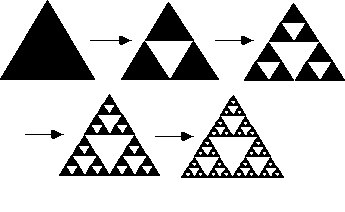

#### Applying Computational Thinking to the problem
The first thing we notice is that the core shape is a triangle (dark).  This triangle is then subdivided into three dark triangles, drawn at the midpoints of the three sides of the initial triangle.  This has the effect of 'removing' an inverted (light) triangle in the center.  The process is repeated for each of the three dark triangles down to a specified depth.  A key property of fractals is self-similarity.  As can be seen from the picture above, the initial triangle is decomposed into three congruent triangles, each of which is half the size of the original.  At each level of depth, we are able to zoom into 3 self-similar copies of the fractal, each with magnification factor 2; i.e. 3^0=1, 3^1=3, 3^2=9, 3^3=27, 3^4=81... etc.

To draw a triangle, we need code that takes three points and joins them up to form a triangle.  Points (or screen coordinates) have an X and a Y component (typical 2D graph logic).  In Python, we use lists (or tuples) to represent screen coordinates.  Given a point P, the convention is for the X coordinate to be placed in P[0] (first element in the list) and the Y coordinate to be placed in P[1] (second element in the list).

The Python code below will be difficult to follow because you are new to the language; don't fret too much about that - we will revisit this problem in the future once you have mastered the underlying Python 3 language elements.  For now, concentrate on the narrative and the process.

In [24]:
from mobilechelonian import Turtle

""" DRAW THE INITIAL TRIANGLE """

def current_location(pen):
    """ returns the current location of the turtle as (x,y) coordinates """
    return(pen.get_state()["points"][0]["x"], pen.get_state()["points"][0]["y"])

def goto(point, pen):
    """ macro to place the turtle in a specific point using simplified syntax """
    pen.setposition(point[0], point[1])
    
def triangle(points, pen):
    """ draws a triangle given three points and a turtle """
    tom.penup()
    goto(points[0], pen)
    tom.pendown()
    goto(points[1], pen)
    goto(points[2], pen)
    goto(points[0], pen)

# create a turtle
tom = Turtle()
tom.speed(10)

# determine the staring location of the turtle (this might vary according to Python distribution)
origin = current_location(tom) # X = origin[0]; Y = origin[1]

# triangles have 3 points and a size (in screen units)
size = 200
point1 = (origin[0]-size, origin[1]+size//2)
point2 = (origin[0], origin[1]-size)
point3 = (origin[0]+size, origin[1]+size//2)

# draw the initial triangle
triangle([point1, point2, point3], tom)


Turtle()

This is the base case, which is an equilateral triangle of 200 units (this size fits the screen nicely).  The next step is to draw three triangles within this triangle, at the midpoints of each side.

A new function midpoint(A,B) is added to calculate the midpoint of the vector between A and B. We first call the triangle function and then for each of the three points of the triangle, we calculate the midpoint of the two vectors linked to that point and draw a triangle that links these three points.

In [ ]:
from mobilechelonian import Turtle

""" DRAW THE INITIAL TRIANGLE AND THEN SUBDIVIDE AT THE MIDPOINTS """

def current_location(pen):
    """ returns the current location of the turtle as (x,y) coordinates """
    return(pen.get_state()["points"][0]["x"], pen.get_state()["points"][0]["y"])

def goto(point, pen):
    """ macro to place the turtle in a specific point using simplified syntax """
    pen.setposition(point[0], point[1])
    
def midpoint(A, B):
    """ calculate the midpoint of a vector between points A and B """
    x = (A[0] + B[0]) // 2
    y = (A[1] + B[1]) // 2
    return(x,y)
    
def triangle(points, pen):
    """ draws a triangle given three points and a turtle """
    tom.penup()
    goto(points[0], pen)
    tom.pendown()
    goto(points[1], pen)
    goto(points[2], pen)
    goto(points[0], pen)

# create a turtle
tom = Turtle()
tom.speed(10)

# determine its location
origin = current_location(tom)

# triangles have 3 points and a size
size = 200
point1 = (origin[0]-size, origin[1]+size//2)
point2 = (origin[0], origin[1]-size)
point3 = (origin[0]+size, origin[1]+size//2)

# draw the initial triangle
triangle([point1, point2, point3], tom)

# draw top sub-triangle
triangle([point2, midpoint(point2, point3), midpoint(point2, point1)], tom)
# draw left sub-triangle
triangle([point1, midpoint(point1, point2), midpoint(point1, point3)], tom)
# draw right sub-triangle
triangle([point3, midpoint(point3, point2), midpoint(point3, point1)], tom)



This is now a Sierpinski Triangle of depth 1, but we should at least draw it to depth 3.  To do this, we must abstract the process to the general case using induction; or what we call recursion in programming parlance.  By modifying the above code we can achieve this result.

A new function sierpinski(depth, points, pen) is added.  This function does exactly what the previous version of this code did; i.e. it draws a triangle and then three sub-triangles which connect the three corners to their closest midpoints.  We can now call this function recursively, with a depth variable - the larger this value, the more complicated the picture becomes.

You can modify the value of depth to see the effect:
sierpinski(depth=3, points=[point1, point2, point3], pen=tom)

In [9]:
from mobilechelonian import Turtle

def current_location(pen):
    """ returns the current location of the turtle as (x,y) coordinates """
    return(pen.get_state()["points"][0]["x"], pen.get_state()["points"][0]["y"])

def goto(point, pen):
    """ macro to place the turtle in a specific point using simplified syntax """
    pen.setposition(point[0], point[1])
    
def midpoint(A, B):
    """ calculate the midpoint of a vector between points A and B """
    x = (A[0] + B[0]) // 2
    y = (A[1] + B[1]) // 2
    return(x,y)
    
def triangle(points, pen):
    """ draws a triangle given three points and a turtle """
    tom.penup()
    goto(points[0], pen)
    tom.pendown()
    goto(points[1], pen)
    goto(points[2], pen)
    goto(points[0], pen)
    
def sierpinski(depth, points, pen):
    # draw the triangle
    triangle(points, pen)
    # then draw the sub-triangles
    if depth > 0:
        # draw top sub-triangle
        sierpinski(depth-1, [points[1], midpoint(points[1], points[2]), midpoint(points[1], points[0])], pen)
        # draw left sub-triangle
        sierpinski(depth-1, [points[0], midpoint(points[0], points[1]), midpoint(points[0], points[2])], pen)
        # draw right sub-triangle
        sierpinski(depth-1, [points[2], midpoint(points[2], points[1]), midpoint(points[2], points[0])], pen)
    

# create a turtle
tom = Turtle()
tom.speed(10)

# determine its location
origin = current_location(tom)

# triangles have 3 points and a size
size = 200
point1 = (origin[0]-size, origin[1]+size//2)
point2 = (origin[0], origin[1]-size)
point3 = (origin[0]+size, origin[1]+size//2)

# change my depth to 5 or 3 and see what happens
sierpinski(depth=4, points=[point1, point2, point3], pen=tom)


Turtle()

Through the use of CT, we are able to break down the problem of drawing a Sierpinski triangle into a smaller problem (i.e. that of drawing a triangle).  We noticed a recurring pattern (i.e. sub-triangles at each corner of the triangle) and abstracted this pattern to the general case and introduced a depth parameter to control the degree of complexity we desired.  We then wrote a list of instructions (i.e. algorithm) and expressed our solution in Python 3.

## B. WORKED EXAMPLE: Calculating the Square Root
Our second problem is approximating the square root of a positive number, that is not already a perfect square itself, without using a calculator. 
1. https://en.wikipedia.org/wiki/Methods_of_computing_square_roots

Note: Python has a math module which has its own square root function.  We will not realistically calculate the square root using any of these methods beyond this point.  We merely examine doing so in order to practice using the CT process.

In [ ]:
import math

x = 25
y = math.sqrt(x)
print(x, y)

Nonetheless, the first-century Greeks were not fortunate enough to have Python at their disposal.  Your goal, therefore, is to calculate the square root of a number by hand as guided by the CT process.


### Algorithm 1: Exhaustive Enumeration (aka guess and check)

If we want to calculate the square root of x, this algorithmic technique enumerates all possibilities (i.e. 0 >= guess <= x) until the right answer is derived or the space of possibilities has been exhausted. Surprisingly, exhaustive enumeration algorithms are often the most practical way to solve a problem. They are typically easy to implement and easy to understand. And, in many cases, they run fast enough for all practical purposes -- Guttag, John V. Introduction to Computation and Programming Using Python (MIT Press)

In this case, millions of guesses are required, so it runs more slowly the larger the value being calculated.  This may not be ideal, but it is a good start.  For this reason, we will implement algorithms in Python because this harnesses the power of the computer, to our advantage.

1. Decomposition: finding the sqrt(x) entails solving the equation f(x) = x^2 - S = 0; for x > 0.  Note: if S=0, what does that say about x?
2. Pattern recognition: A "guess and check" methods involves a guesstimate g and checking g^2 - S against the value of f(x).
3. Abstraction: given x and an accuracy parameter S, you iteratively refine a guesstimate g and check whether g^2 - S = 0.  The computation does not depend on x and S; however, x>0 and S must be relatively small to be useful.
4. Algorithm Design: take inputs x and S as principal value and the accuracy setting; using guess g check if g^2 - S = 0; if not then modify g somehow and then keep checking until your modification of g is such that g^2 - S = 0.

In [6]:
""" 
    Calculate the square root using exhaustive enumeration 
    Adapted from Introduction to Computation and Programming Using Python
    by Wayne Dalton
"""

x = 200      # we want the square root of x
S = 0.001    # how accurate do we want the result?
step = S**2  # how big is the increment between successive guesses?

guess = 0    # we did say it will be exhaustive ...
count = 0    # counter for interations of algorithm

while abs(guess**2 - x) >= S and guess < x:
    guess = guess + step
    count = count + 1

if abs(guess**2 - x) >= S:
    print('[-] failed to calculate square root of', x)
else:
    print('[+] the square root of', x, 'is approximately', guess)
    print('[*] Computation took', count, 'iterations')

[+] the square root of 200 is approximately 14.142100996167567
[*] Computation took 14142101 iterations


Whilst this method works, and is sufficiently accurate, it is not very efficient.  The larger the value of x, the higher the number of iterations necessary for the algorithm to converge on a good guess for the square root.  The graph below illustrates this; note it takes over 14 million interations to computer the square root of 200.

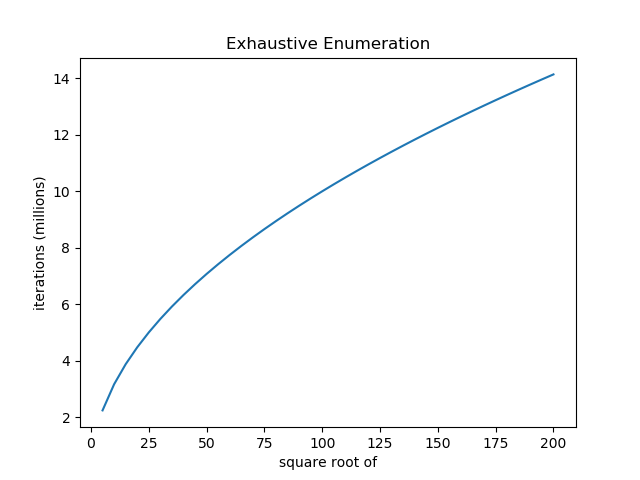

### Algorithm 2: Bisection Method
A method that is more computationally efficient is the bisection method. 

The bisection method repeatedly bisects an interval and then selects a subinterval in which a root must lie for further processing. It is a very simple and robust method, but it is also relatively slow. Because of this, it is often used to obtain a rough approximation to a solution which is then used as a starting point for more rapidly converging methods. The method is also called the interval halving.  

1. https://en.wikipedia.org/wiki/Bisection_method


In [7]:
""" 
    Calculate the square root using bisection method
    Adapted from Introduction to Computation and Programming Using Python
    by Wayne Dalton
"""

x = 200    # we want the square root of x
S = 0.001  # how accurate do we want the estimate?
count = 0  # how many loops do we perform before obtaining a result?

# determine interval in which the root must lie
low = 0.0
high = max(1.0, x)

# initial guess (informed by the interval size)
guess = (high + low) / 2

while abs(guess**2 - x) > S:
    if guess**2 < x:
        low = guess  # adjust lower bounds of interval
    else:
        high = guess # adjust upper bounds of the interval
    count += 1
    guess = (high + low) / 2  # update the guess

if abs(guess**2 - x) >= S:
    print('[-] failed to calculate square root of', x)
else:
    print('[+] the square root of', x, 'is approximately', guess)
    print('Computation took', count, 'iterations')

[+] the square root of 200 is approximately 14.142131805419922
Computation took 20 iterations


This is an order of magnitude improvement over exhaustive enumeration.  It requires significantly less iterations to yield good approximations and therefore runs much faster.

Reflection: how does computational thinking help you solve a problem like this?

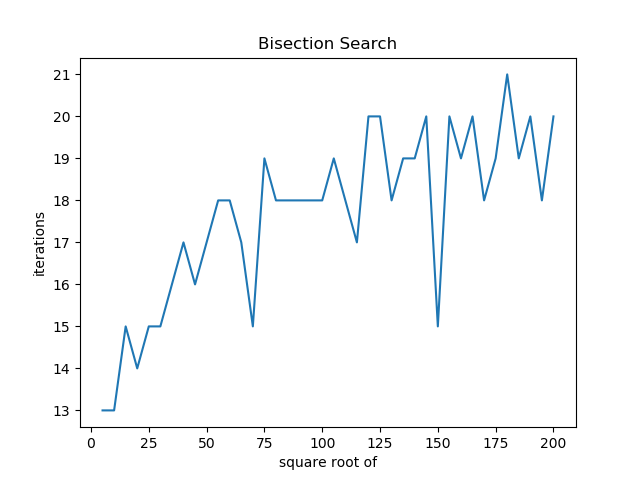

### Algorithm 3: Newton-Raphson Method (aka successive approximation)
The method most commonly used algorithm is Newton's method.  Finding the root of a number R can be formulated as finding x such that x^2 - R = 0.  

Newton proved a theorem that implies that if a value, call it guess, is an approximation to a root of a polynomial, then guess – p(guess)/p’(guess), where p’ is the first derivative of p, is a better approximation.

For any constant k and any coefficient c, the first derivative of cx2 + k is 2cx. For example, the first derivative of x2 – k is 2x. Therefore, we know that we can improve on the current guess, call it y, by choosing as our next guess y - (y2 - k)/2y. This is called successive approximation.

Guttag, John V.. Introduction to Computation and Programming Using Python (MIT Press)

In [8]:
""" 
    Calculate the square root using Newton's method
    Adapted from Introduction to Computation and Programming Using Python
    by Wayne Dalton
"""

x = 200    # we want to calculate the square root of x
S = 0.001  # how accurate do we want the approximation?
count = 0  # count the number of iterations

guess = x / 2.0  # make an initial guess

# Newton-Raphson incrementally make successively better approximations for the root of a function
while abs(guess**2 - x) >= S:
    guess = guess - (((guess**2) - x) / (2 * guess)) # Xn+1 = Xn - f(Xn)/f'(Xn) where f'(Xn) is the derivate of Xn
    count += 1

if abs(guess**2 - x) >= S:
    print('[-] failed to calculate square root of', x)
else:
    print('[+] the square root of', x, 'is approximately', guess)
    print('Computation took', count, 'iterations')

[+] the square root of 200 is approximately 14.142135968022693
Computation took 6 iterations



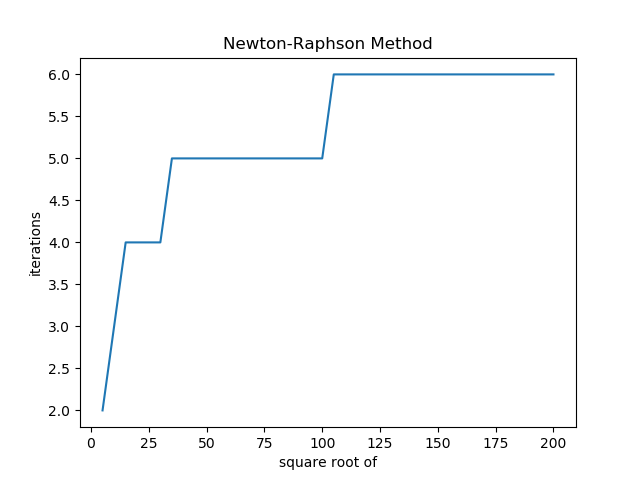

## C. WORKED EXAMPLE: Towers of Hanoi

The Tower of Hanoi puzzle was invented by the French mathematician Edouard Lucas in 1883. He was inspired by a legend that tells of a Hindu temple where the puzzle was presented to young priests.  This ancient temple has a large room with three towers surrounded by 64 golden disks. These disks are continuously moved by priests in the temple. According to a prophecy, when the last move of the puzzle is completed the world will end. These priests acting on the prophecy, follow the immutable rule of moving these disk one at a time. 

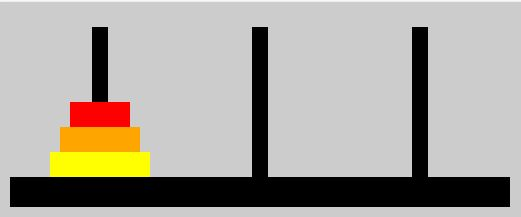

The Tower of Hanoi problem, depicted above, presents three pegs (or towers) and n disks placed one over the other. The n disks are initially all stacked on a single peg.  The objective of the puzzle is to move the stack to any another peg following these simple rules.

1. Only one disk can be moved at a time.
2. No disk can be placed on top of the smaller disk.

#### Solving the 3-disk puzzle
Our goal is to move the 3 disks from peg 1 to peg 3, by following lord Brahma's rules.  If we label each peg (or tower) individually (e.g. A, B, C) the following moves are optimal:

1. Move from peg A to peg C
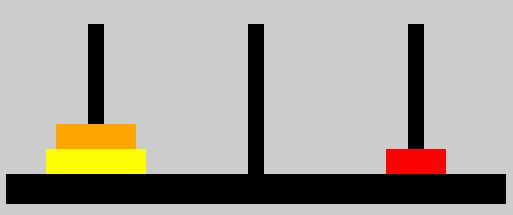

2. Move from peg A to peg B
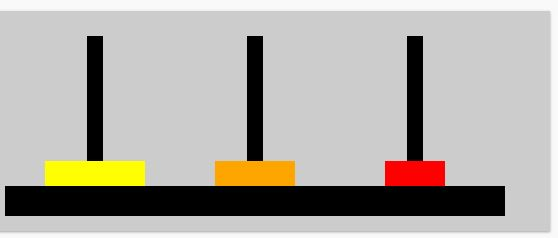

3. Move from peg C to peg B
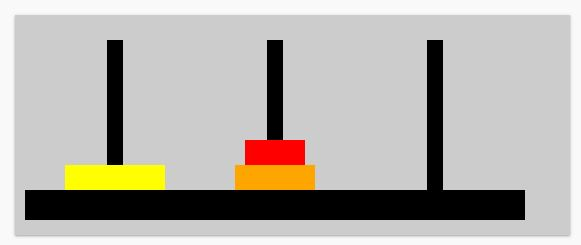

4. Move from peg A to peg C
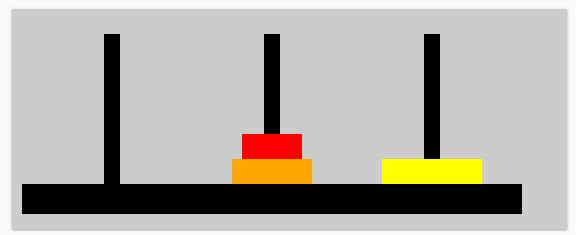

5. Move from peg B to peg A
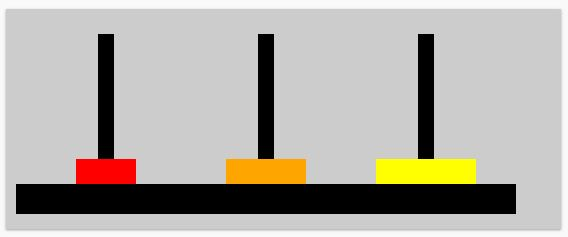

6. Move from peg B to peg C
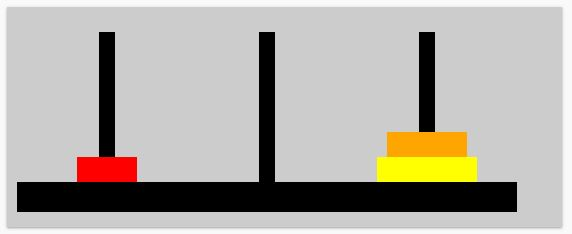

7. Move from peg A to peg C
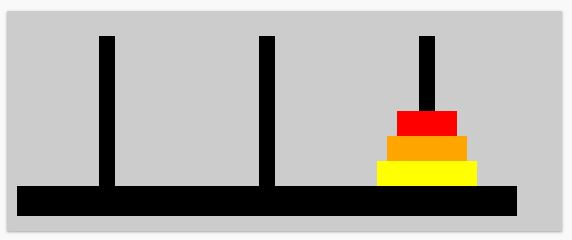

The optimal solution to the 3-disk problem requires a minimum of 7 moves.  In fact, the minimum number of moves for the n-disk problem is 2^n - 1.  If each move took 1 second to perform, the 64-disk puzzle would take 584 billion years to complete!


In [9]:
num_disks = 64 # number of disks
moves = (2**num_disks) - 1
print("The {}-disk problem requires minimum of {} moves".format(num_disks, moves))

time_per_move = 1 #second
minutes = (moves * time_per_move) / 60
hours = minutes / 60
days = hours / 24
years = days / 365
billions_of_years = years / 1000000000

print("It would take {:.3f} billions of years to complete the puzzle".format(billions_of_years))

The 64-disk problem requires minimum of 18446744073709551615 moves
It would take 584.942 billions of years to complete the puzzle


## Towards a general solution of the problem
Using pen and paper, solve this problem for a 4-disk, 5-disk and 6-disk configurations.
Take note of the following:
1. Are there any recurring patterns in your solution?
2. Are the patterns the same for even- and odd-numbered configurations?
3. Is there a way to exploit these recurring patterns?

#### Trivial Case
In this case of a single disk, you simply move the single disk from its starting peg to the peg you selected as the destination.  This is not really a puzzle.  So we consider the trivial case as a puzzle involving at least 2 disks.  

It is helpful to talk about the three pegs using their roles (i.e. source, destination and auxillary).  If we label the pegs as "A", "B" and "C", we can designate "A" as the source (where the disks start from).  If we subsequently choose "C" as the peg we want to move all the disks to (i.e. the destination), then that leaves "B" as the auxillary peg.

Remember, when moving the disks, we are not allowed to place a larger disc on top of a smaller disk.  It is therefore helpful to designate disks by their number; e.g. if we have 2 disks, then disk 1 is considered smaller than disk 2, so disk 1 will always be placed ont top of disk 2.

#### Solution to 2-disk Towers of Hanoi: {Source=A, Destination=C, Auxillary=B}
1. A -> B
2. A -> C
3. B -> C

Solution in 3 moves (2^n - 1; with n=2)

#### Solution to 3-disk Towers of Hanoi: {Source=A, Destination=C, Auxillary=B}
1. A -> C
2. A -> B
3. C -> B
4. A -> C
5. B -> A
6. B -> C
7. A -> C

Solution in 7 moves (2^n - 1; with n=3)


## Challenge
Write down a general algorithm for solving the n-disk Towers of Hanoi problem.

In [26]:
def move(disk, Source, Destination):
    """ print the result of a move """
    print('Move disk {} : {} => {}'.format(disk, Source, Destination))
    
def towers(n, Source, Destination, Auxillary):
    if n==1:
        move(n, Source, Destination)
        return
    towers(n-1, Source, Auxillary, Destination)
    move(n, Source, Destination)
    towers(n-1, Auxillary, Destination, Source)
 
N = 3
towers(N, Source="A", Destination="B", Auxillary="C")


Move disk 1 : A => B
Move disk 2 : A => C
Move disk 1 : B => C
Move disk 3 : A => B
Move disk 1 : C => A
Move disk 2 : C => B
Move disk 1 : A => B


# Looking Ahead

As already stated, this module is about applying computational thinking to classical and real-world computing problems.  The language of choice for expressing your solutions to these problems is Python 3.  Tthe recommended distribution of Python 3 is Anaconda.  You are encouraged to download and install Anaconda on your own personal computer because this module will require a lot of programming on your part.


You can download and install the latest version from the link below:
1. https://www.anaconda.com/download/ <=== primary download link (bigger download, no effort later)
2. https://www.python.org/downloads/ <=== alternative link if you want vanilla python (smaller download, more effort later)

Anaconda is the industry standard Python distribution for science, data science and machine learning.  It convenient comes with all of the most popular libraries pre-installed.  You can choose to download Python from link 2 but then you must install the libraries yourself.  If you are new to Python, then you are better off with link 1.